### Iqram Haris Fahromi
#### ID: 975120354

In [138]:
# !pip install obspy
# !pip install cartopy
# !pip install utm

In [139]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from obspy.core import UTCDateTime
from obspy.clients.fdsn import Client
import utm
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pyproj import Transformer
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

# I. **Pre-Processing**

#### I.1 Download seismic data

In [140]:
client = Client("GEONET")

events = client.get_events(eventid = "2013p203051")
event = events[0]
origin = event.origins[0]
ev_time = origin.time

t1 = UTCDateTime(ev_time)-60 # start time
t2 = t1 + 180 # end time

# Download waveform data
stream_etaz = client.get_waveforms(network='NZ', station="ETAZ", location="10", channel="***", starttime=t1, endtime=t2)

stream_kbaz = client.get_waveforms(network='NZ', station="KBAZ", location="10", channel="***", starttime=t1, endtime=t2)

stream_rvaz = client.get_waveforms(network='NZ', station="RVAZ", location="10", channel="***", starttime=t1, endtime=t2)

stream_epaz = client.get_waveforms(network='NZ', station="EPAZ", location="10", channel="***", starttime=t1, endtime=t2)
#stream_etaz.plot();

#### I.2 Download event data

In [141]:
events = client.get_events(eventid="2013p203051")

event_data = []

for ev in events:
    origin = ev.preferred_origin() or (ev.origins[0] if ev.origins else None)
    magnitude = ev.preferred_magnitude() or (ev.magnitudes[0] if ev.magnitudes else None)

    if origin:
        ev_id = str(ev.resource_id).split('/')[-1] if ev.resource_id else None

        event_dict = {
            "event_id": ev_id,
            "time": origin.time.datetime,
            "latitude": origin.latitude,
            "longitude": origin.longitude,
            "depth_km": origin.depth / 1000.0 if origin.depth is not None else None,
        }
        event_data.append(event_dict)
df_events = pd.DataFrame(event_data)

# Convert event coordinate to UTM
def convert_stations_to_utm(row):
    try:
        east, north, _, _ = utm.from_latlon(
            row['latitude'],
            row['longitude'],
            #force_zone_number=60
        )
        return pd.Series([east, north])
    except:
        return pd.Series([None, None])

df_events[['utm_x', 'utm_y']] = df_events.apply(convert_stations_to_utm, axis=1)
df_events

,event_id,time,latitude,longitude,depth_km,utm_x,utm_y
0,2013p203051,2013-03-17 03:05:42.951052,-36.763052,174.915072,7.285156,313905.521187,5.929385e+06


#### I.3 Download station data

In [142]:
# Download stations data
data = []
stream = stream_epaz + stream_etaz + stream_rvaz + stream_kbaz

for tr in stream:
    net = tr.stats.network
    sta = tr.stats.station
    loc = tr.stats.location
    cha = tr.stats.channel

    try:
        inv = client.get_stations(network=net, station=sta, location=loc, channel=cha, level="station")
        station = inv[0][0]

        data.append({"network": net, "station": sta, "location": loc, "channel": cha,
                     "latitude": station.latitude, "longitude": station.longitude,"elevation_m": station.elevation})
    except:
        print(f"Failed: {sta}")

df_stations = pd.DataFrame(data)
df_stations = df_stations.drop_duplicates(subset=["station"])
df_stations['elevation_km'] = df_stations['elevation_m']/1000

# Convert event coordinate to UTM
def convert_stations_to_utm(row):
    try:
        east, north, _, _ = utm.from_latlon(
            row['latitude'],
            row['longitude'],
            #force_zone_number=60
        )
        return pd.Series([east, north])
    except:
        return pd.Series([None, None])

df_stations[['utm_x', 'utm_y']] = df_stations.apply(convert_stations_to_utm, axis=1)
df_stations

,network,station,location,channel,latitude,longitude,elevation_m,elevation_km,utm_x,utm_y
0,NZ,EPAZ,10,EH1,-36.875472,174.743594,40.0,0.040,298892.258440,5.916565e+06
3,NZ,ETAZ,10,EH1,-36.953500,174.927800,195.0,0.195,315500.324849,5.908280e+06
6,NZ,RVAZ,10,EH1,-36.769996,174.579199,59.0,0.059,283941.258631,5.927909e+06
9,NZ,KBAZ,10,EH1,-37.094683,174.888552,12.0,0.012,312353.162593,5.892538e+06


# II. **Phase Picking**

#### Final arrival time onset

In [143]:
# Station ETAZ
P_abs_etaz = UTCDateTime("2013-03-17T03:05:48.244")
S_abs_etaz = UTCDateTime("2013-03-17T03:05:51.014")

# Station EPAZ
P_abs_epaz = UTCDateTime("2013-03-17T03:05:48.495")
S_abs_epaz = UTCDateTime("2013-03-17T03:05:51.226")

# Station RVAZ
P_abs_rvaz = UTCDateTime("2013-03-17T03:05:50.332")
S_abs_rvaz = UTCDateTime("2013-03-17T03:05:54.557")

# Station KBAZ
P_abs_kbaz = UTCDateTime("2013-03-17T03:05:51.184")
S_abs_kbaz = UTCDateTime("2013-03-17T03:05:55.965")

#### Function for plotting arrival time onset

In [144]:
def plot_function(stream, P_arrival, S_arrival, station_name, onset_p="", onset_s=""):
    # arrival relative
    P_arrival_relative = P_arrival - stream_etaz[0].stats.starttime
    S_arrival_relative = S_arrival - stream_etaz[0].stats.starttime

    fig, axs = plt.subplots(3, 1, figsize=(10, 6), sharex=True, gridspec_kw={"hspace": 0})

    for i in range(3):
        stream = stream.select(channel="*Z") + stream.select(channel="*1") + stream.select(channel="*2")
        data = stream[i].data
        data_norm = data / np.max(np.abs(data)) ################ normalize data

        axs[i].plot(stream[i].times(), data_norm, 'k', label = stream[i].stats.channel)

    for i in range(3):
        axs[i].legend(loc='upper right')

    for i in range(3):
        axs[i].axvline(P_arrival_relative, color='blue', linestyle='--', label='P')
        axs[i].axvline(S_arrival_relative, color='red', linestyle='--', label='S')

    axs[0].legend(loc='upper right')

    axs[-1].set_xlabel("Time (seconds)")

    axs[0].set_title(f"Station: {station_name}")
    plt.text(P_arrival_relative-0.35, 4.1, f"{onset_p}", color = "blue")
    plt.text(S_arrival_relative-0.25, 2, f"{onset_s}", color = "red")
    plt.xlim(P_arrival_relative-3, S_arrival_relative+4)
    #plt.tight_layout()
    plt.show()

#### II.1 Plot station ETAZ

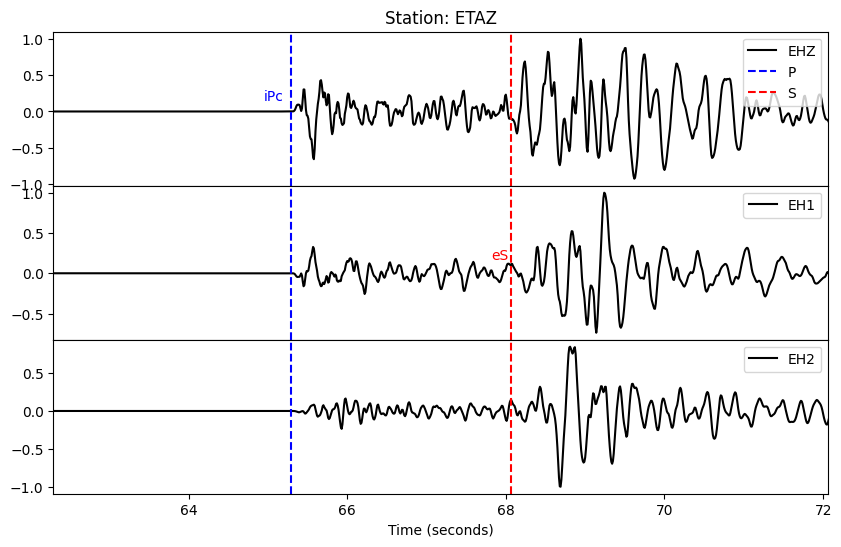

In [145]:
plot_function(stream_etaz, P_abs_etaz, S_abs_etaz, station_name="ETAZ", onset_p="iPc", onset_s="eS")

#### II.2 Plot Station EPAZ

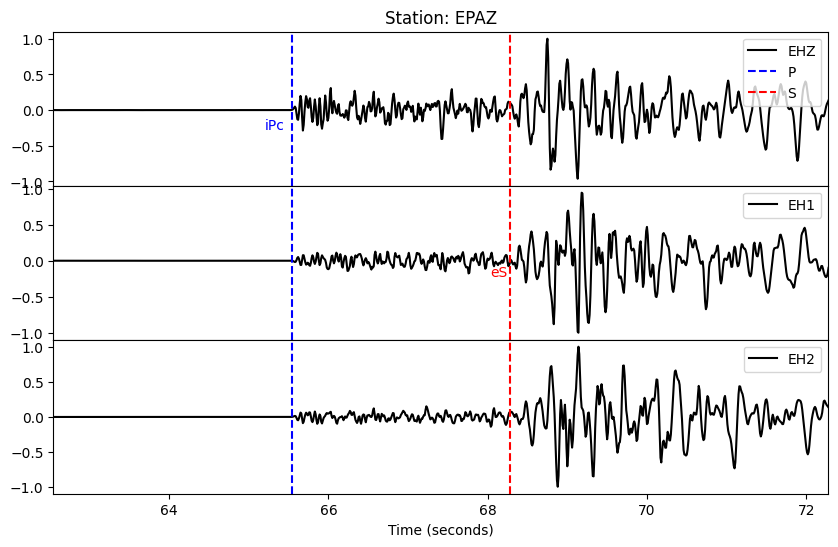

In [146]:
plot_function(stream_epaz, P_abs_epaz, S_abs_epaz, station_name="EPAZ", onset_p="iPc", onset_s="eS")

#### II.3 Plot Station RVAZ

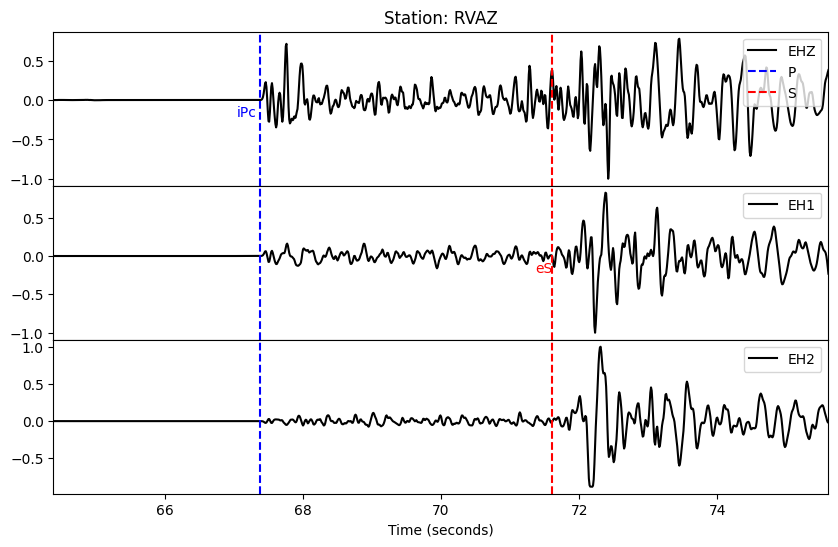

In [147]:
plot_function(stream_rvaz, P_abs_rvaz, S_abs_rvaz, station_name="RVAZ", onset_p="iPc", onset_s="eS")

####II.4 Plot Station KBAZ

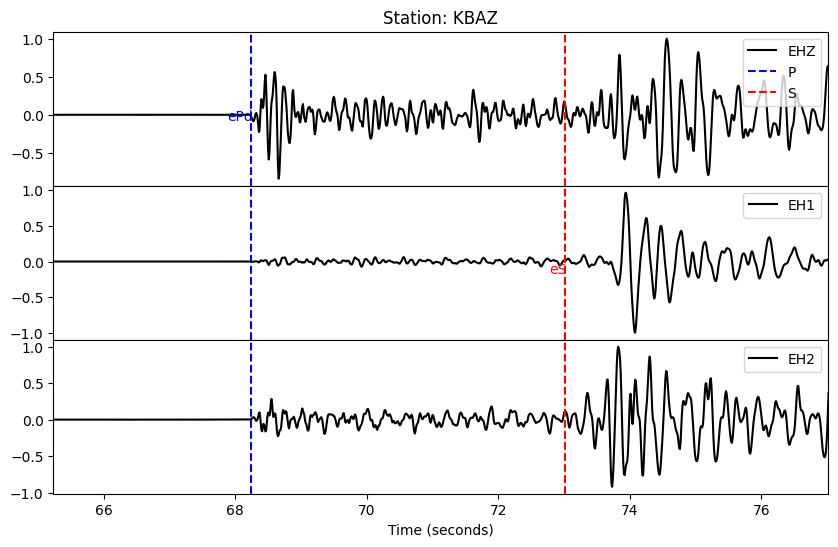

In [148]:
plot_function(stream_kbaz, P_abs_kbaz, S_abs_kbaz, station_name="KBAZ", onset_p="ePd", onset_s="eS")

# **III. Inversion**

#### III.1 Equations explanation

We have:
$$
T_i = T_0 + \frac{r_i}{v} \tag 1
$$

$$
r_i = \sqrt{(x_i-x_0)^{2}+(y_i-y_0)^{2}+(z_i-z_0)^{2}} \tag 2
$$

Thus, substituting equation (2) into (1):

$$
T_i = T_0 + \frac{1}{v} \sqrt{(x_i-x_0)^{2}+(y_i-y_0)^{2}+(z_i-z_0)^{2}} \tag 3
$$

Equation (3) is non-linear with respect to the model parameters
$(x_0, y_0, z_0, T_0)$. Therefore, we linearize it using a first-order
Taylor expansion around an initial model $(x_0^0, y_0^0, z_0^0, T_0^0)$:

$$
T_i \approx T_i^0
+ \frac{\partial T}{\partial x_0} \Delta x_0
+ \frac{\partial T}{\partial y_0} \Delta y_0
+ \frac{\partial T}{\partial z_0} \Delta z_0
+ \Delta T_0
\tag 4
$$

Define the residual:
$$
\Delta T_i = T_i^{obs} - T_i^{calc} \tag 5
$$

The partial derivatives are:
$$
\frac{\partial T}{\partial x_0} = \frac{x_0 - x_i}{v r_i}
$$

$$
\frac{\partial T}{\partial y_0} = \frac{y_0 - y_i}{v r_i}
$$

$$
\frac{\partial T}{\partial z_0} = \frac{z_0 - z_i}{v r_i}
$$

$$
\frac{\partial T}{\partial T_0} = 1
$$

Thus, equation (4) becomes:

$$
\Delta T_i =
\frac{x_0 - x_i}{v r_i} \Delta x_0 +
\frac{y_0 - y_i}{v r_i} \Delta y_0 +
\frac{z_0 - z_i}{v r_i} \Delta z_0 +
\Delta T_0
\tag 6
$$

This can be written in matrix form:

$$
\Large\mathbf{A m = d}
\tag 7
$$

where:

$$
A =
\begin{bmatrix}
\frac{x_0 - x_1}{v r_1} & \frac{y_0 - y_1}{v r_1} & \frac{z_0 - z_1}{v r_1} & 1 \\
\frac{x_0 - x_2}{v r_2} & \frac{y_0 - y_2}{v r_2} & \frac{z_0 - z_2}{v r_2} & 1 \\
\frac{x_0 - x_3}{v r_3} & \frac{y_0 - y_3}{v r_3} & \frac{z_0 - z_3}{v r_3} & 1
\end{bmatrix}
$$

$$
m =
\begin{bmatrix}
\Delta x_0 \\
\Delta y_0 \\
\Delta z_0 \\
\Delta T_0
\end{bmatrix}
$$

$$
d =
\begin{bmatrix}
T_1^{obs} - T_1^{calc} \\
T_2^{obs} - T_2^{calc} \\
T_3^{obs} - T_3^{calc}
\end{bmatrix}
$$

Finally, the solution is obtained using least squares:

$$
\Large\mathbf{m = (A^T A)^{-1} A^T \Delta d}
\tag 8
$$

#### III.2 Model parameters

In [149]:
# Params
# Syntetic model hypocenter / GEONET Database
x0 = df_events['utm_x'].values
y0 = df_events['utm_y'].values
z0 = df_events['depth_km'].values*-1

# references hypocenter for inversion / initial model
m_ref = [x0[0]-200, y0[0]-1000, -2]

# travel time V and T0
t0 = 0
vp = 5.94 # assume (km/s)
vs = 3.39 # assume (kms/s)

# observation stations
xs = df_stations['utm_x'].values
ys = df_stations['utm_y'].values
zs = df_stations['elevation_km'].values
print("Initial/reference hypocenter:", m_ref)

Initial/reference hypocenter: [np.float64(313705.52118745167), np.float64(5928385.471651691), -2]


#### III.3 Travel time function

In [150]:
# function for calculate travel time
def travel_time(xhipo, yhipo, zhipo, xsi, ysi, zsi, vp=5.94, vs=3.39):
  ti_vp = np.sqrt((xsi-xhipo)**2 + (ysi-yhipo)**2 + (zsi-zhipo)**2)/(vp)
  ti_vs = np.sqrt((xsi-xhipo)**2 + (ysi-yhipo)**2 + (zsi-zhipo)**2)/(vs)

  return ti_vs-ti_vp

In [151]:
# calculate travel time observation
d_obs = travel_time(x0, y0, z0, xs, ys, zs, vp=vp, vs=vs)
print("Travel time obsevation:", d_obs)

Travel time obsevation: [2500.09971749 2680.33971067 3799.1305517  4670.29974842]


#### III.4 Pseudo-code

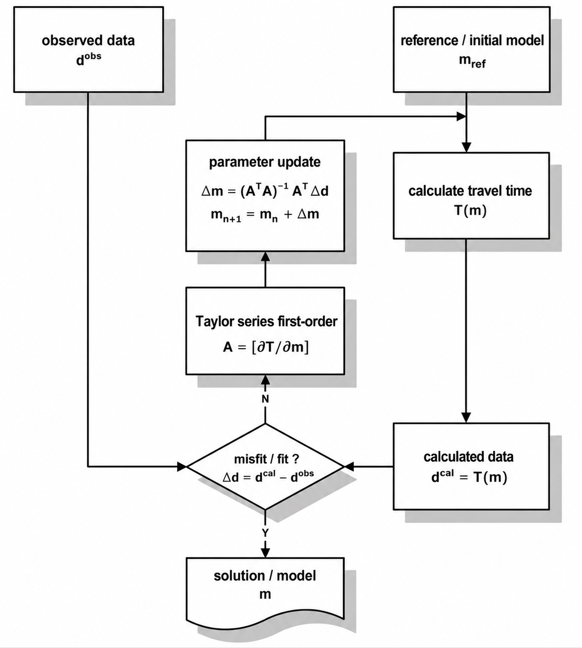

##### Figure 1. Pseudo-code for non-linear inversion algorithm with linearized solution (Modified from Grandis, 2009).

#### III.5 Main inversion process

RMS iteration 1:
103.17061275562249
RMS iteration 2:
4478.460008323133
RMS iteration 3:
2651.3606261874934
RMS iteration 4:
172.66881153205665
RMS iteration 5:
34.763886592949
RMS iteration 6:
7.253307594040936
RMS iteration 7:
1.7704166775880312
RMS iteration 8:
0.44010520859402763
RMS iteration 9:
0.10983925835918197
RMS iteration 10:
0.027412888401544554
RMS iteration 11:
0.006815148509338736
RMS iteration 12:
0.0016668635288056592
RMS iteration 13:
0.0003821341093580084
RMS iteration 14:
6.849291353434556e-05
RMS iteration 15:
5.345772740928679e-06
RMS iteration 16:
4.572925767195402e-08
RMS iteration 17:
1.670848457331325e-12
RMS iteration 18:
5.569494857771083e-13
RMS iteration 19:
0.0


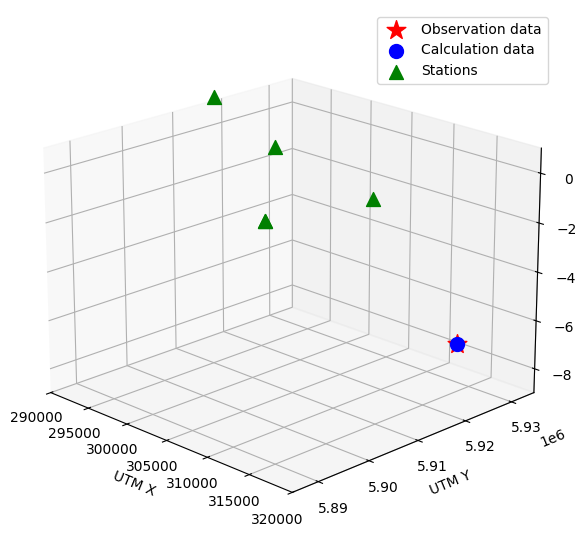

In [152]:
iteration = 50
misfit = np.array([np.inf])

# Initial/reference model
m_ref = [x0[0]-200, y0[0]-1000, -2]

# Store hypocenter trajectory for each iteration
trajectory = [m_ref.copy()]

for i in range(iteration):
    # Calculate travel times
    d_calc = travel_time(m_ref[0], m_ref[1], m_ref[2], xs, ys, zs)

    # Compute error with Root Mean Square Error (RMSE)
    delta_d = d_obs-d_calc
    rms = np.sqrt(np.mean(delta_d**2))
    misfit = np.append(misfit, rms)

    print(f'RMS iteration {i+1}:')
    print(rms)

    # Check for convergence or tolerance threshold
    if np.isclose(misfit[i], misfit[i-1]) or misfit[i] <= 1e-20:
        break
    else:
      # Construct the Kernel/Jacobian matrix (Partial derivatives / Taylor series first-order)
      dtdx0_vp = (m_ref[0]-xs)/(vp*np.sqrt((m_ref[0]-xs)**2 + (m_ref[1]-ys)**2 + (m_ref[2]-zs)**2))
      dtdy0_vp = (m_ref[1]-ys)/(vp*np.sqrt((m_ref[0]-xs)**2 + (m_ref[1]-ys)**2 + (m_ref[2]-zs)**2))
      dtdz0_vp = (m_ref[2]-zs)/(vp*np.sqrt((m_ref[0]-xs)**2 + (m_ref[1]-ys)**2 + (m_ref[2]-zs)**2))

      dtdx0_vs = (m_ref[0]-xs)/(vs*np.sqrt((m_ref[0]-xs)**2 + (m_ref[1]-ys)**2 + (m_ref[2]-zs)**2))
      dtdy0_vs = (m_ref[1]-ys)/(vs*np.sqrt((m_ref[0]-xs)**2 + (m_ref[1]-ys)**2 + (m_ref[2]-zs)**2))
      dtdz0_vs = (m_ref[2]-zs)/(vs*np.sqrt((m_ref[0]-xs)**2 + (m_ref[1]-ys)**2 + (m_ref[2]-zs)**2))

      A_matrix = np.column_stack([dtdx0_vs-dtdx0_vp, dtdy0_vs-dtdy0_vp, dtdz0_vs-dtdz0_vp])

      # Solve the linearized inverse problem (Least Squares)
      m_calc = np.linalg.inv((A_matrix.T).dot(A_matrix)).dot(A_matrix.T).dot(delta_d)

      # Update model parameters
      m_ref = m_calc + m_ref

      # Save updated hypocenter position
      trajectory.append(m_ref.copy())

### Vizs
fig = plt.figure(figsize=(7,7))
ax = plt.axes(projection='3d')
for i in range(0,10,3):
    ax.scatter(df_stations['utm_x'][i], df_stations['utm_y'][i], df_stations['elevation_km'][i], marker="^", color="green", s=100)

ax.scatter(x0, y0, z0, label="Observation data", color="red", marker="*", s=200)
ax.scatter(m_ref[0], m_ref[1], m_ref[2], label="Calculation data", color="blue", s=100)
ax.scatter(df_stations['utm_x'][i], df_stations['utm_y'][i], df_stations['elevation_km'][i],
           marker="^", color="green", s=100, label="Stations")

ax.legend()
ax.set_title("")
ax.set_xlabel("UTM X")
ax.set_ylabel("UTM Y")
ax.set_zlabel("Z (km)")

ax.set_xlim(295000-5000, 315000+5000)
ax.set_ylim(5885*10e2, 5935*10e2)
ax.set_zlim(-9, 1)
ax.view_init(elev=20, azim=-45)
plt.show()

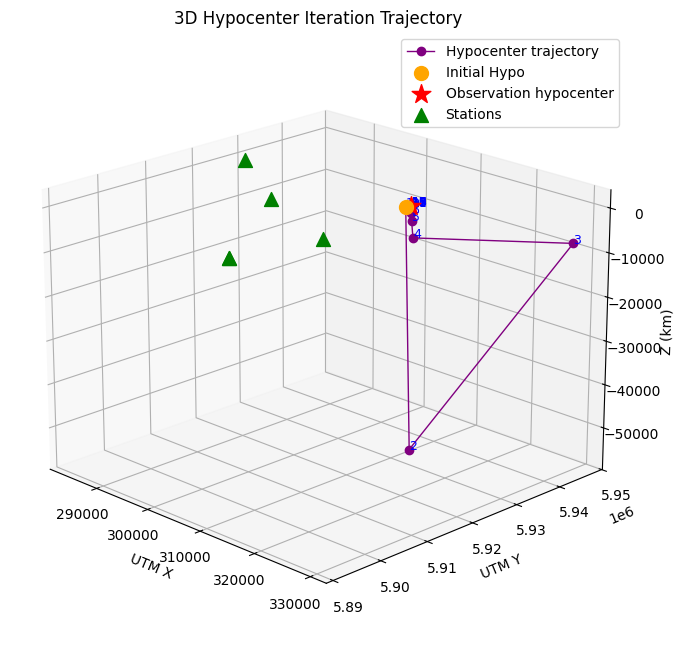

In [153]:
trajectory = np.array(trajectory)

fig = plt.figure(figsize=(8,8))
ax = plt.axes(projection='3d')

# Trajectory line
ax.plot(trajectory[:,0], trajectory[:,1], trajectory[:,2], linewidth=1, marker='o', label='Hypocenter trajectory', color='purple')

# Initial model
ax.scatter(trajectory[0,0], trajectory[0,1], trajectory[0,2], color='orange', s=100, label='Initial Hypo')

# Iteration labels
for i in range(len(trajectory)):
    ax.text(trajectory[i,0], trajectory[i,1], trajectory[i,2], f'{i+1}', fontsize=9, color='blue')

# Observation / true hypocenter
ax.scatter(x0, y0, z0, color='red', marker='*', s=200, label='Observation hypocenter')

for i in range(0,10,3):
    ax.scatter(df_stations['utm_x'][i], df_stations['utm_y'][i], df_stations['elevation_km'][i], marker="^", color="green", s=100)
ax.scatter(df_stations['utm_x'][i], df_stations['utm_y'][i], df_stations['elevation_km'][i],
           marker="^", color="green", s=100, label="Stations")

ax.set_xlabel("UTM X")
ax.set_ylabel("UTM Y")
ax.set_zlabel("Z (km)")
ax.set_title("3D Hypocenter Iteration Trajectory")

ax.view_init(elev=20, azim=-45)

ax.legend()

plt.show()

#### III.6 Plot Misfit

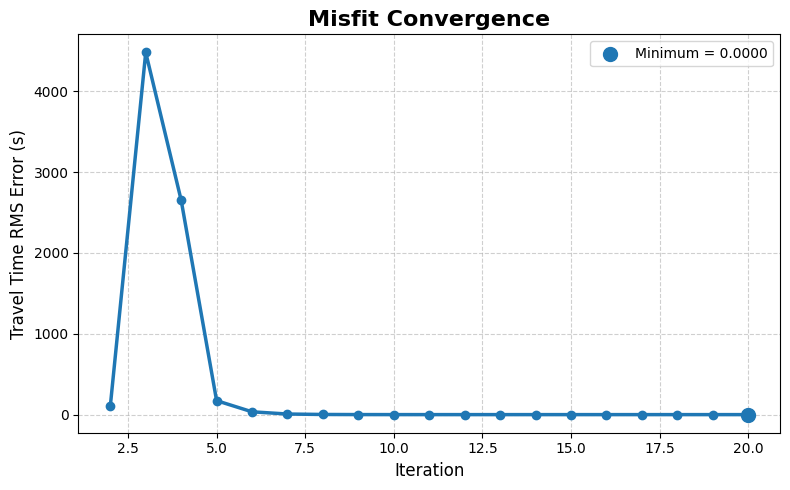

In [154]:
iteration = np.arange(1, len(misfit)+1)

plt.figure(figsize=(8,5))

plt.plot(iteration, misfit, marker='o', linewidth=2.5, markersize=6)

# highlight minimum misfit
min_idx = np.argmin(misfit)
plt.scatter(iteration[min_idx], misfit[min_idx], s=100, zorder=5, label=f"Minimum = {misfit[min_idx]:.4f}")

plt.title("Misfit Convergence", fontsize=16, fontweight='bold')
plt.xlabel("Iteration", fontsize=12)
plt.ylabel("Travel Time RMS Error (s)", fontsize=12)

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()

In [155]:
# Final residual hypocenter
print(f'Residual UTM x: {abs(m_ref[0]-x0)[0]/1000:.20f} km')
print(f'Residual UTM y: {abs(m_ref[1]-y0)[0]/1000:.20f} km')
print(f'Residual z    : {abs(m_ref[2]-z0)[0]/1000:.20f} km')

Residual UTM x: 0.00000000000000000000 km
Residual UTM y: 0.00000000000000000000 km
Residual z    : 0.00000000000146886325 km


#### III.7 Final plot

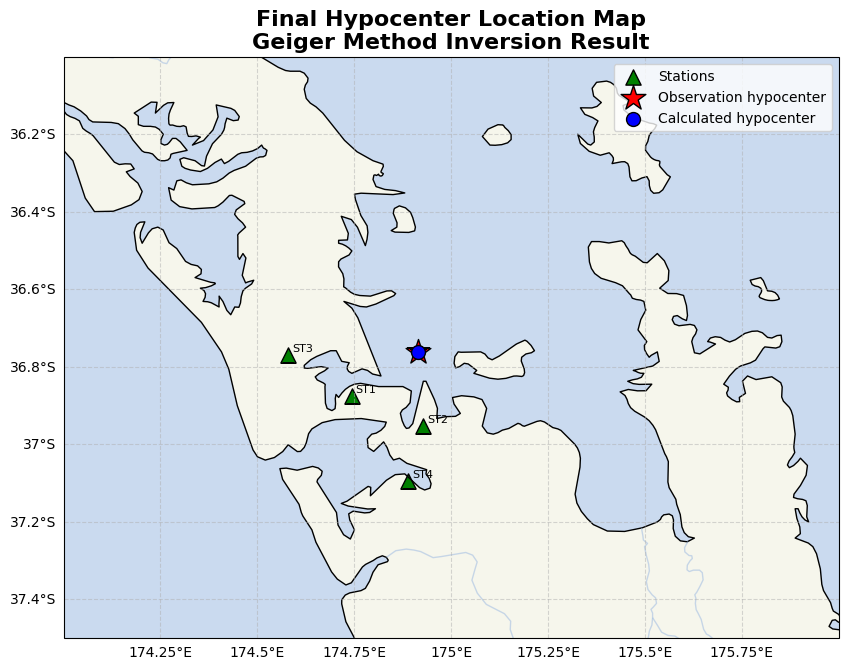

In [156]:
transformer = Transformer.from_crs("EPSG:32760", "EPSG:4326", always_xy=True)

# Stations
station_lon, station_lat = transformer.transform(df_stations['utm_x'].values, df_stations['utm_y'].values)

# Observation hypocenter
obs_lon, obs_lat = transformer.transform(x0[0], y0[0])

# Calculated hypocenter
calc_lon, calc_lat = transformer.transform(m_ref[0], m_ref[1])


fig = plt.figure(figsize=(10,10))
ax = plt.axes(projection=ccrs.PlateCarree())

buffer = 0.15

ax.set_extent([min(station_lon.min(), obs_lon, calc_lon) - buffer, max(station_lon.max(), obs_lon, calc_lon) + buffer,
    min(station_lat.min(), obs_lat, calc_lat) - buffer, max(station_lat.max(), obs_lat, calc_lat) + buffer])

ax.add_feature(cfeature.LAND, alpha=0.5)
ax.add_feature(cfeature.OCEAN, alpha=0.5)
ax.add_feature(cfeature.COASTLINE, linewidth=1)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.RIVERS, alpha=0.5)

gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
gl.top_labels = False
gl.right_labels = False

ax.scatter(station_lon, station_lat, marker='^', s=120, edgecolor='black', color='green', label='Stations', transform=ccrs.PlateCarree())

# Station labels
for i in range(len(station_lon)):
    ax.text(station_lon[i] + 0.01, station_lat[i] + 0.01, f'ST{i+1}', fontsize=8, transform=ccrs.PlateCarree())

ax.scatter(obs_lon, obs_lat, marker='*', s=350, edgecolor='black', color='red', label='Observation hypocenter', transform=ccrs.PlateCarree())
ax.scatter(calc_lon, calc_lat, marker='o', s=100, edgecolor='black', color='blue', label='Calculated hypocenter', transform=ccrs.PlateCarree())
ax.plot([obs_lon, calc_lon], [obs_lat, calc_lat], linestyle='--', linewidth=2, transform=ccrs.PlateCarree())

ax.set_title('Final Hypocenter Location Map\nGeiger Method Inversion Result', fontsize=16, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend(loc='upper right')
ax.set_extent([174, 176, -36, -37.5])
plt.show()

# IV. Conclusions

- Geiger’s method solves the non-linear earthquake hypocenter problem by linearizing the travel-time equation using first-order Taylor series expansion (partial derivatives/Jacobian matrix).
- The inversion process is iterative, where model parameters are continuously updated until the RMS misfit converges to a minimum value.
- Combining Vp and Vs travel times improves inversion stability and hypocenter accuracy because S-wave information provides additional constraints on the source location.
- The quality of inversion results strongly depends on data quality, noise level, the initial/reference model, and consistent physical units throughout the forward modeling and inversion process.

# V. Reference

- Geiger, L. (1912). _Probability method for the determination of earthquake epicenters from the arrival time only_. Bulletin of St. Louis University, 8, 60–71.
- Grandis, H. (2009). *Pengantar Inversi Geofisika*. Jakarta: Himpunan Ahli Geofisika Indonesia (HAGI).

#### **AI Disclosure**

This report was prepared with the assistance of artificial intelligence (AI) tools, including ChatGPT by OpenAI, to support language refinement, coding assistance, visualization improvement, and explanation of inversion concepts. All calculations, interpretations, and final conclusions were reviewed and validated by the author. The author remains fully responsible for the accuracy, originality, and academic integrity of the submitted work.